In [10]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_parquet("../data/processed/application_processed.parquet")

In [12]:
print(df.shape)
print(df.head())
print(df.columns)

(307511, 136)
   NAME_CONTRACT_TYPE  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0           -0.324395     -0.717914         0.664531     -0.623536   
1           -0.324395     -0.717914        -1.504820     -0.623536   
2            3.082659      1.392925         0.664531     -0.623536   
3           -0.324395     -0.717914         0.664531     -0.623536   
4           -0.324395     -0.717914         0.664531     -0.623536   

   AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0          0.655160   -0.220419    -0.164393        -0.273155   
1          1.260100    1.419719     0.641054         1.379129   
2         -1.654998   -1.782978    -1.479012        -1.623983   
3         -0.197453   -0.592633     0.200761        -0.509324   
4         -0.419005    0.109019    -0.372016         0.263339   

   REGION_POPULATION_RELATIVE  DAYS_BIRTH  ...  \
0                   -0.144308    1.506880  ...   
1                   -1.269054   -0.166821  ...   
2                   -0.7

In [13]:
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

In [14]:
X.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X.columns
]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [16]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    scale_pos_weight=12,
    random_state=42
)

In [17]:
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032897 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8564
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 126
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.69      0.81     56538
           1       0.17      0.70      0.27      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.69      0.76     61503



In [20]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.7609658888885682


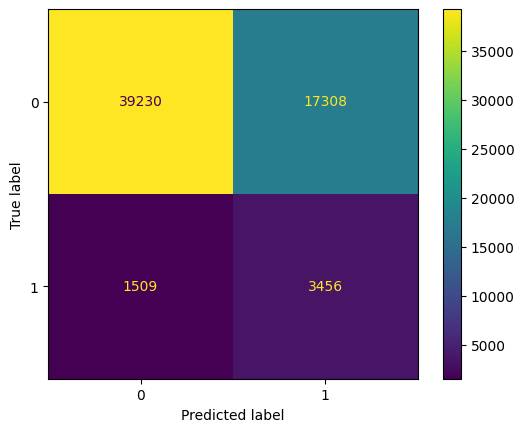

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [22]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                         feature  importance
29                  EXT_SOURCE_1         613
31                  EXT_SOURCE_3         592
9                     DAYS_BIRTH         526
30                  EXT_SOURCE_2         523
5                     AMT_CREDIT         515
6                    AMT_ANNUITY         471
7                AMT_GOODS_PRICE         370
12               DAYS_ID_PUBLISH         365
10                 DAYS_EMPLOYED         361
65        DAYS_LAST_PHONE_CHANGE         349
11             DAYS_REGISTRATION         345
4               AMT_INCOME_TOTAL         238
8     REGION_POPULATION_RELATIVE         234
22       HOUR_APPR_PROCESS_START         165
59                TOTALAREA_MODE         113
92                 CODE_GENDER_M         111
43  YEARS_BEGINEXPLUATATION_MODE         103
91    AMT_REQ_CREDIT_BUREAU_YEAR         103
90     AMT_REQ_CREDIT_BUREAU_QRT          94
1                   FLAG_OWN_CAR          89


In [23]:
joblib.dump(model, "../models/lightgbm_model.joblib")

['../models/lightgbm_model.joblib']

In [24]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

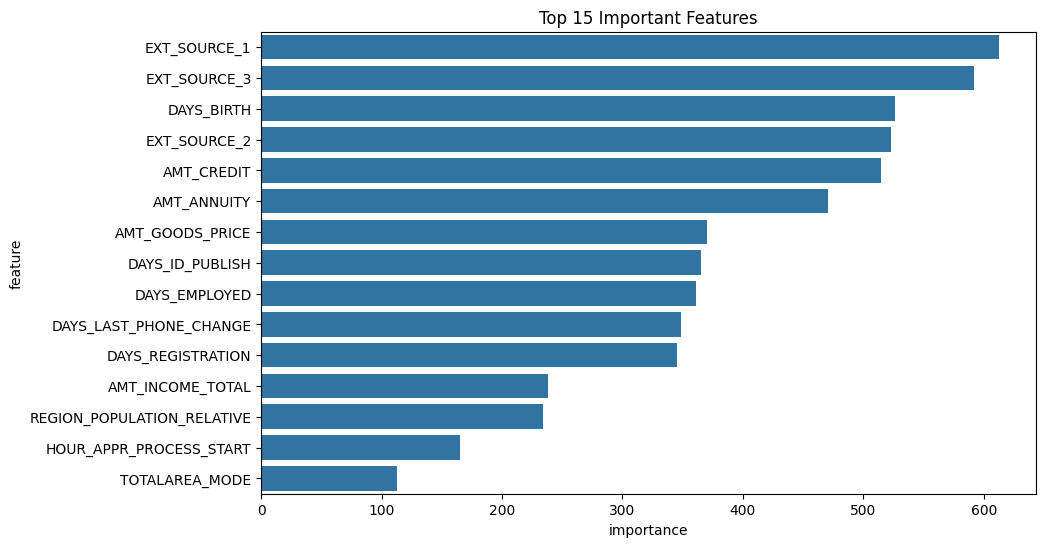

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=importance_df.head(15)
)

plt.title("Top 15 Important Features")

plt.savefig("../assets/charts/feature_importance.png")

plt.show()

In [26]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

/Users/adhilmuhammed/Documents/GitHub/Credit_Risk_Platform/venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


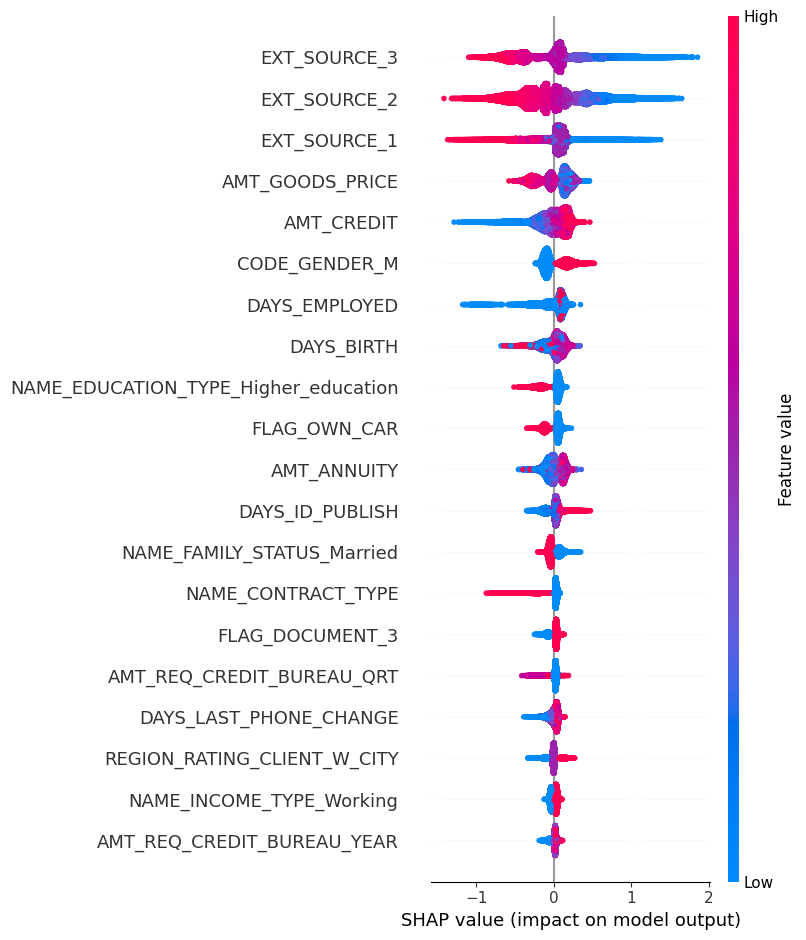

In [27]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig("../assets/charts/shap_summary.png")

plt.show()

In [30]:
sample = X_test.iloc[0]


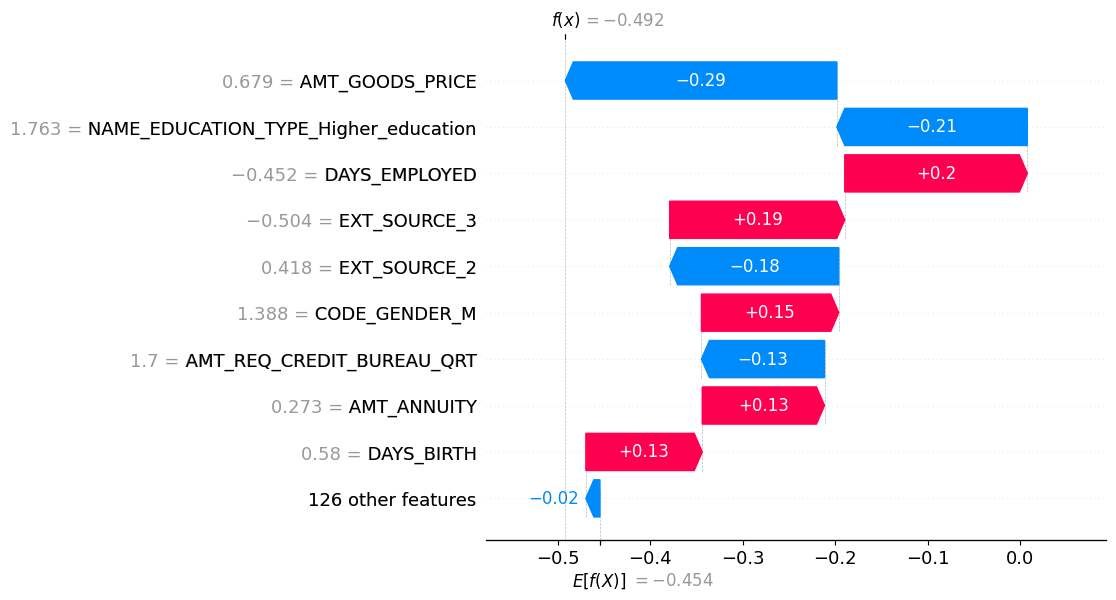

In [37]:
sample_index = 0

exp = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_index],
    feature_names=X_test.columns
)

shap.plots.waterfall(exp, show=False)

plt.savefig(
    "../assets/charts/shap_waterfall.png",
    bbox_inches="tight"
)

plt.show()

In [33]:
shap_values.shape

(61503, 135)

In [34]:
shap_values[0][0]

np.float64(0.04418232378708509)

In [36]:
plt.savefig("../assets/charts/shap_waterfall.png")

<Figure size 640x480 with 0 Axes>

In [38]:
importance_df.to_csv(
    "../models/feature_importance.csv",
    index=False
)

In [39]:
sample_input = X_test.iloc[[0]]

prediction = model.predict_proba(sample_input)[:,1][0]

print(prediction)

0.3794932996575611


In [40]:
top_features = importance_df.head(5)["feature"].tolist()

print("Top model drivers:")
print(top_features)

Top model drivers:
['EXT_SOURCE_1', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'EXT_SOURCE_2', 'AMT_CREDIT']


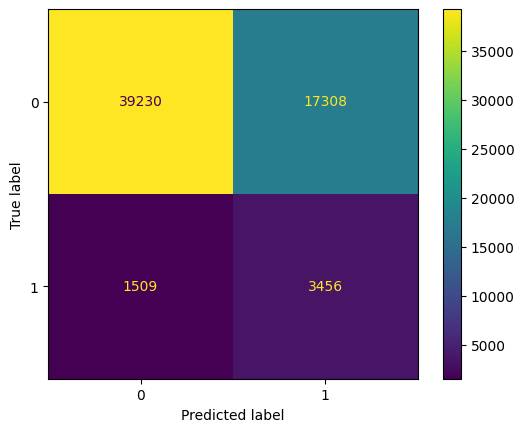

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.savefig(
    "../assets/charts/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()